In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (accuracy_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
!pip install xgboost
from xgboost import XGBClassifier


from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
TH = pd.read_csv(
    "../classification/TomsHardware/Absolute_labeling/TomsHardware-Absolute-Sigma-500.data",
    sep=",",
    header=None
)



groups = [
    "NCD", "BL", "NAD", "AI", "NAC", "ND",
    "CS", "AT", "NA", "ADL", "AS_NA", "AS_NAC"
]

columns = []
for group in groups:
    for t in range(8):
        columns.append(f"{group}_{t}")

columns.append("label")  # остання колонка

TH.columns = columns


prefixes = {col.split("_")[0] for col in TH.columns if "_" in col}


TH.head()

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,NCD_7,BL_0,BL_1,...,AS_NA_7,AS_NAC_0,AS_NAC_1,AS_NAC_2,AS_NAC_3,AS_NAC_4,AS_NAC_5,AS_NAC_6,AS_NAC_7,label
0,1,0,0,0,0,0,0,1,1.0,0.0,...,0.001816,0.001211,0.000560,0.000000,0.000000,0.000161,0.0,0.000301,0.000818,1.0
1,1,1,1,1,0,0,0,0,1.0,1.0,...,0.005029,0.000784,0.000802,0.001592,0.001612,0.000741,0.0,0.000545,0.002437,1.0
2,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
3,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
4,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0


In [3]:
!pip install tensorflow

In [4]:
X = TH.drop('label', axis=1)
y = TH['label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(96,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


In [6]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [7]:
history = model.fit(X_train,y_train,epochs=30,batch_size=32,validation_split=0.2)

Epoch 1/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8055 - loss: 0.4295 - val_accuracy: 0.8221 - val_loss: 0.3916
Epoch 2/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8454 - loss: 0.3475 - val_accuracy: 0.8387 - val_loss: 0.3720
Epoch 3/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8618 - loss: 0.3190 - val_accuracy: 0.8522 - val_loss: 0.3477
Epoch 4/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8687 - loss: 0.2968 - val_accuracy: 0.8625 - val_loss: 0.3258
Epoch 5/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8774 - loss: 0.2779 - val_accuracy: 0.8632 - val_loss: 0.3182
Epoch 6/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8830 - loss: 0.2630 - val_accuracy: 0.8625 - val_loss: 0.3131
Epoch 7/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8907 - loss: 0.2507 - val_accuracy: 0.8735 - val_loss: 0.2891
Epoch 8/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8976 - loss: 0.2294 - val_accuracy: 0.

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9070 - loss: 0.2663
Test accuracy: 0.9070208668708801


In [9]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import classification_report, f1_score, confusion_matrix

print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1: 0.9215162840363054
[[571  38]
 [109 863]]
              precision    recall  f1-score   support

         0.0       0.84      0.94      0.89       609
         1.0       0.96      0.89      0.92       972

    accuracy                           0.91      1581
   macro avg       0.90      0.91      0.90      1581
weighted avg       0.91      0.91      0.91      1581



In [10]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[571  38]
 [109 863]]
              precision    recall  f1-score   support

         0.0       0.84      0.94      0.89       609
         1.0       0.96      0.89      0.92       972

    accuracy                           0.91      1581
   macro avg       0.90      0.91      0.90      1581
weighted avg       0.91      0.91      0.91      1581



In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [12]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(96,)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

In [13]:
optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [15]:
history = model.fit(X_train,y_train,epochs=200,batch_size=32,validation_split=0.2)

Epoch 1/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7717 - loss: 0.4772 - val_accuracy: 0.8182 - val_loss: 0.4468
Epoch 2/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8264 - loss: 0.3860 - val_accuracy: 0.8340 - val_loss: 0.3746
Epoch 3/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8349 - loss: 0.3634 - val_accuracy: 0.8490 - val_loss: 0.3527
Epoch 4/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8448 - loss: 0.3432 - val_accuracy: 0.8569 - val_loss: 0.3499
Epoch 5/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8454 - loss: 0.3450 - val_accuracy: 0.8632 - val_loss: 0.3263
Epoch 6/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8618 - loss: 0.3071 - val_accuracy: 0.9051 - val_loss: 0.3517
Epoch 7/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8646 - loss: 0.3055 - val_accuracy: 0.8933 - val_loss: 0.3245
Epoch 8/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8743 - loss: 0.2929 - val_accu

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", accuracy)


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9475 - loss: 0.1296
Test accuracy: 0.9475015997886658


In [17]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.05, 0.95, 19)
best_t, best_f1 = 0.5, -1

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.15
Best F1: 0.9365804160324708


In [18]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import classification_report, f1_score, confusion_matrix

print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
F1: 0.9578037620742247
[[556  53]
 [ 30 942]]
              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93       609
         1.0       0.95      0.97      0.96       972

    accuracy                           0.95      1581
   macro avg       0.95      0.94      0.94      1581
weighted avg       0.95      0.95      0.95      1581



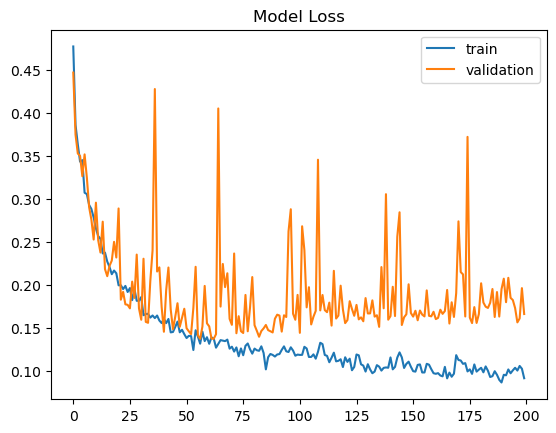

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.title("Model Loss")
plt.show()

In [20]:
X_train_cnn = X_train.reshape(-1, 8, 12)
X_test_cnn = X_test.reshape(-1, 8, 12)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
model = Sequential()

model.add(Conv1D(64, kernel_size=2, activation='relu', input_shape=(8,12)))
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(32, kernel_size=2, activation='relu'))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [25]:
history = model.fit(
    X_train_cnn,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8154 - loss: 0.4163 - val_accuracy: 0.8340 - val_loss: 0.3722
Epoch 2/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8500 - loss: 0.3386 - val_accuracy: 0.8506 - val_loss: 0.3430
Epoch 3/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8697 - loss: 0.3021 - val_accuracy: 0.8696 - val_loss: 0.3010
Epoch 4/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8836 - loss: 0.2672 - val_accuracy: 0.8751 - val_loss: 0.2792
Epoch 5/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8998 - loss: 0.2356 - val_accuracy: 0.9075 - val_loss: 0.2484
Epoch 6/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9150 - loss: 0.2039 - val_accuracy: 0.9154 - val_loss: 0.2301
Epoch 7/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9203 - loss: 0.1881 - val_accuracy: 0.9178 - val_loss: 0.2172
Epoch 8/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9292 - loss: 0.1750 - val_accu

In [26]:
loss, accuracy = model.evaluate(X_test_cnn, y_test)

print("Test accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9292 - loss: 0.1854
Test accuracy: 0.9291587471961975


In [27]:
y_prob = model.predict(X_test_cnn).ravel()
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import classification_report, f1_score

print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
F1: 0.9425051334702259
              precision    recall  f1-score   support

         0.0       0.91      0.90      0.91       609
         1.0       0.94      0.94      0.94       972

    accuracy                           0.93      1581
   macro avg       0.93      0.92      0.93      1581
weighted avg       0.93      0.93      0.93      1581



In [28]:
import pandas as pd

nn_results = pd.DataFrame({
    "Model": [
        "Neural Network (Simple)",
        "Neural Network (Improved)",
        "CNN (Convolutional Neural Network)"
    ],
    
    "Architecture": [
        "Dense(64) → Dense(32) → Dense(1)",
        "Dense(128) → BatchNorm → Dropout → Dense(64) → BatchNorm → Dropout → Dense(32) → Dense(1)",
        "Conv1D(64) → MaxPooling → Conv1D(32) → Flatten → Dense(64) → Dropout → Dense(1)"
    ],
    
    "Epochs": [
        30,
        200,
        200
    ],
    
    "Batch Size": [
        32,
        32,
        32
    ],
    
    "Accuracy": [
        0.90,
        0.94,
        0.927
    ],
    
    "F1-score": [
        0.92,
        0.953,
        0.942
    ]
})

nn_results.round(3)

,Model,Architecture,Epochs,Batch Size,Accuracy,F1-score
0,Neural Network (Simple),Dense(64) → Dense(32) → Dense(1),30,32,0.900,0.920
1,Neural Network (Improved),Dense(128) → BatchNorm → Dropout → Dense(64) →...,200,32,0.940,0.953
2,CNN (Convolutional Neural Network),Conv1D(64) → MaxPooling → Conv1D(32) → Flatten...,200,32,0.927,0.942
